# Thesis Artifact Analysis

- Reads benchmark results from `outputs/AllClear/intersection_samples`, writes plots/tables to `outputs/thesis/`.
- Reproduce everything in one command:
  ```
  jupyter nbconvert --to notebook --execute --inplace analysis/notebooks/thesis_artifact_analysis.ipynb
  ```
- **Models:** `LeastCloudy` (baseline), `Mosaicing`, `VPint2`, `UnCRtainTS`, `EMRDM` — 5 cloud-removal methods, same 366 scenes.
- **Structure:** Setup → RQ1 → RQ2 → RQ3 → qualitative samples. Each plot/table has a short note above it explaining what it shows.

## Setup

- Imports, file paths, and constants used everywhere below (model list, metric names, cloud bins, colors).
- Defined once here so we don't repeat it in every section.

In [1]:
import datetime
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# This notebook lives at analysis/notebooks/; nbconvert executes with cwd = the notebook's
# own directory by default, so two levels up is the repo root.
ROOT = Path.cwd().parent.parent
DATA_ROOT = ROOT / "outputs" / "AllClear" / "intersection_samples"
OUT_ROOT = ROOT / "outputs" / "thesis"
OUT_PLOTS = OUT_ROOT / "plots"
OUT_TABLES = OUT_ROOT / "tables"
OUT_PLOTS.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)

MODELS = ["LeastCloudy", "Mosaicing", "VPint2", "UnCRtainTS", "EMRDM"]
BASELINE = "LeastCloudy"
# LeastCloudy and Mosaicing just select/composite observed pixels; they are the
# reference point, not methods under test. Kept separate in tables and figures.
BASELINES = ["LeastCloudy", "Mosaicing"]
LEARNED = [m for m in MODELS if m not in BASELINES]

# RMSE is left out of the thesis table: psnr = 20*log10(1/rmse) per scene, so the two rank
# every scene identically. PSNR is kept because the reference publications report it.
RECON_METRICS = ["MAE", "PSNR", "SAM", "SSIM"]

# What each method actually receives. Shown in the RQ1 table so its ranking is read in context.
MODEL_INPUTS = {
    "LeastCloudy": "1 frame",
    "Mosaicing": "3 frames",
    "VPint2": "2 frames",
    "UnCRtainTS": "3 frames + SAR",
    "EMRDM": "1 cloudy frame + SAR",
}
RATIO_METRICS = ["NDVI_MAE", "NBR_MAE"]  # spectral-index reconstruction error
HIGHER_IS_BETTER = {"PSNR", "SSIM"}  # every other metric here is lower-is-better

CLOUD_BIN_EDGES = [0, 10, 30, 60, 100.0001]
CLOUD_BIN_LABELS = ["0-10", "10-30", "30-60", "60-100"]

# Dynamic World land cover classes (used by benchmark.py for LULC plots)
DW_CLASS_NAMES = {
    0: "water", 1: "trees", 2: "grass", 3: "flooded_veg", 4: "crops",
    5: "shrub_scrub", 6: "built", 7: "bare", 8: "snow_ice",
}

# Figures are drawn at their final print size so LaTeX never rescales them: a figure placed
# at width=X\textwidth is created X * TEXT_WIDTH_IN inches wide. Keeps label sizes identical
# across every figure. 418.25pt is this document's \textwidth.
TEXT_WIDTH_IN = 418.25 / 72.27

# Matplotlib's defaults assume a large canvas; at print size they are far too big.
plt.rcParams.update({
    "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
})

RNG_SEED = 42
N_BOOTSTRAP = 2000

# Deeper shades than matplotlib-bright defaults: these sit next to the muted greys, sage and
# clay used in the RQ1/RQ2 figures, and pale fills wash out on the printed page.
MODEL_COLORS = {
    "LeastCloudy": "#64748b", "Mosaicing": "#2563eb", "VPint2": "#0f9d76",
    "UnCRtainTS": "#c2820a", "EMRDM": "#d1493f",
}

### Loading the data

- Each model produced 3 CSVs: per-sample (`*_metadata.csv`), dataset mean (`*_aggregated_metrics.csv`), per-land-cover-class mean (`*_lulc_metrics.csv`).
- We load all 5 models and stack them into one long table each, tagged with a `model` column.
- `avg_cld_percent` is a **per-scene** property: all models are given the same input frames, so the cloud cover of a scene is the same number for every model. We bin it into `cloud_bin` here and use those shared bins in RQ3.

In [2]:
def load_metadata_all():
    frames = []
    for model in MODELS:
        df = pd.read_csv(DATA_ROOT / f"{model}_metadata.csv")
        df["model"] = model
        frames.append(df)
    long_df = pd.concat(frames, ignore_index=True)
    long_df = long_df.rename(columns={
        "mae": "MAE", "rmse": "RMSE", "psnr": "PSNR", "sam": "SAM", "ssim": "SSIM",
        "ndvi_mae": "NDVI_MAE", "nbr_mae": "NBR_MAE",
    })
    # Cloud cover belongs to the scene, not the model, so take one value per data_id
    # and reuse it for every model. (Older UnCRtainTS artifacts report a wrong value
    # here because its wrapper overwrote the mask before benchmark.py read it.)
    scene_cloud = (
        long_df.loc[long_df.model == BASELINE].set_index("data_id")["avg_cld_percent"] * 100.0
    )
    long_df["cloud_pct"] = long_df["data_id"].map(scene_cloud)
    long_df["cloud_bin"] = pd.cut(
        long_df["cloud_pct"], bins=CLOUD_BIN_EDGES, labels=CLOUD_BIN_LABELS,
        include_lowest=True, right=False,
    )
    return long_df


def load_aggregated_all():
    frames = []
    for model in MODELS:
        df = pd.read_csv(DATA_ROOT / f"{model}_aggregated_metrics.csv")
        df.insert(0, "model", model)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def load_lulc_all():
    frames = []
    for model in MODELS:
        df = pd.read_csv(DATA_ROOT / f"{model}_lulc_metrics.csv")
        df.insert(0, "model", model)
        frames.append(df)
    long_df = pd.concat(frames, ignore_index=True)
    long_df["class_name"] = long_df["class"].map(DW_CLASS_NAMES)
    return long_df


long_df = load_metadata_all()
agg_df = load_aggregated_all()
lulc_df = load_lulc_all()
long_df.head()

,data_id,avg_cld_percent,avg_shdw_percent,consistent_cld_percent,consistent_shdw_percent,MAE,RMSE,PSNR,SAM,SSIM,NDVI_MAE,NBR_MAE,model,cloud_pct,cloud_bin
0,roi374230_2022-04-13_2022-04-28,0.208669,0.194509,0.0,0.0,0.009677,0.011117,39.080257,3.364488,0.947876,0.019765,0.029871,LeastCloudy,20.866904,10-30
1,roi821071_2022-08-22_2022-09-06,0.172699,0.117228,0.0,0.0,0.038323,0.041408,27.658279,16.322121,0.765519,0.111454,0.229247,LeastCloudy,17.269897,10-30
2,roi454383_2022-11-23_2022-12-08,0.320552,0.000000,0.0,0.0,0.024679,0.036117,28.845760,3.489689,0.961098,0.015429,0.012638,LeastCloudy,32.055157,30-60
3,roi368690_2022-03-30_2022-04-14,0.031387,0.138234,0.0,0.0,0.011914,0.014814,36.586842,2.726170,0.976402,0.043183,0.034100,LeastCloudy,3.138733,0-10
4,roi533648_2022-03-29_2022-04-13,0.336060,0.000488,0.0,0.0,0.014863,0.018714,34.556622,8.181637,0.896961,0.138313,0.170200,LeastCloudy,33.605957,30-60


### Fairness check

- Confirms all 5 models report on the exact same 366 samples, so the comparisons above are apples-to-apples.

In [3]:
def fairness_check(long_df):
    id_sets = {m: set(long_df.loc[long_df.model == m, "data_id"]) for m in MODELS}
    ref_ids = id_sets[BASELINE]
    all_equal = all(ids == ref_ids for ids in id_sets.values())
    notes = [f"All models share identical sample ID sets: {all_equal} (n={len(ref_ids)} each)."]
    if not all_equal:
        for m in MODELS:
            diff = ref_ids.symmetric_difference(id_sets[m])
            if diff:
                notes.append(f"  - {m} differs from {BASELINE} by {len(diff)} sample IDs.")
    return "\n".join(notes)


fairness_notes = fairness_check(long_df)
print(fairness_notes)

All models share identical sample ID sets: True (n=366 each).


## RQ1: Reconstruction quality

- How close is each model's output to the real (cloud-free) image, in raw pixel/spectral terms?
- Metrics: MAE, RMSE, PSNR, SAM, SSIM, plus NDVI_MAE/NBR_MAE (also used in RQ2).
- Lower is better for MAE/RMSE/SAM/NDVI_MAE/NBR_MAE. Higher is better for PSNR/SSIM.
- The two baselines are listed separately from the three benchmarked methods, as is usual in the cloud-removal literature: they are a reference point, not methods under test.

In [4]:
# Baselines first, then the learned methods.
ORDERED = BASELINES + LEARNED
rq1_main_table = (agg_df.set_index("model")
                  .loc[ORDERED, [*RECON_METRICS, *RATIO_METRICS, "num_samples"]]
                  .reset_index())
rq1_main_table.to_csv(OUT_TABLES / "rq1_main_metric_table.csv", index=False)
rq1_main_table

,model,MAE,PSNR,SAM,SSIM,NDVI_MAE,NBR_MAE,num_samples
0,LeastCloudy,0.018575,35.585178,4.301271,0.947296,0.038960,0.063652,366
1,Mosaicing,0.017573,34.930599,3.861471,0.949238,0.034865,0.055888,366
2,VPint2,0.032183,30.302994,6.663805,0.914724,0.067113,0.100560,366
3,UnCRtainTS,0.025628,31.806288,6.745858,0.927700,0.081764,0.105704,366
4,EMRDM,0.030241,30.785490,6.960315,0.905710,0.073162,0.113564,366


### How often is each method the most accurate?

- The table above gives averages. An average can hide what is going on: a method could be slightly better on most scenes, or roughly equal on most scenes but ruined by a few very bad ones.
- Both cases produce the same average, so the table cannot tell them apart.
- Here we count, for every one of the 366 scenes separately, which method had the lowest MAE on that scene.
- If the baselines win on most individual scenes, their advantage is real and not caused by a handful of failures elsewhere.


In [5]:
# Which method reconstructs a given scene most accurately? Counted scene by scene, so a
# method that wins narrowly everywhere and one that wins hugely on a few scenes look different.
def win_share(models, metric):
    per_scene = long_df[long_df.model.isin(models)].pivot(
        index="data_id", columns="model", values=metric)
    best = per_scene.idxmax(axis=1) if metric in HIGHER_IS_BETTER else per_scene.idxmin(axis=1)
    return (best.value_counts() / len(per_scene) * 100).reindex(models).fillna(0)


# Three fills for the whole figure: one dark and two lighter. They differ in hue *and* in
# lightness, so they stay tellable apart in greyscale print and under colour-vision deficiency.
DARK, SAGE, CLAY = "#334155", "#a4c3b2", "#e29578"
EMPH, MUTED = DARK, SAGE
STACK_FILL = {"UnCRtainTS": DARK, "VPint2": SAGE, "EMRDM": CLAY}

fig, (ax_a, ax_b) = plt.subplots(
    2, 1, figsize=(TEXT_WIDTH_IN, 4.9), dpi=200, gridspec_kw={"height_ratios": [3.5, 6.5]})

# (a) all five methods, MAE only -- the baselines' lead, scene by scene
share_all = win_share(MODELS, "MAE").sort_values()
bars = ax_a.barh(share_all.index, share_all.values,
                 color=[EMPH if m in BASELINES else MUTED for m in share_all.index])
for bar, v in zip(bars, share_all.values):
    ax_a.text(v + 0.8, bar.get_y() + bar.get_height() / 2, f"{v:.1f}%", va="center")
ax_a.set_xlim(0, max(share_all.values) * 1.25)
ax_a.set_xlabel("share of the 366 scenes with the lowest MAE (%)")
ax_a.set_title("(a) all five methods, pixel error", loc="left")

# (b) the three benchmarked methods only, one group per metric. Bars all start at zero so
# a method's share can be compared across metrics -- that comparison is the point of the panel.
import numpy as np
y = np.arange(len(RECON_METRICS))
h = 0.27
for k, model in enumerate(LEARNED):
    vals = [win_share(LEARNED, m)[model] for m in RECON_METRICS]
    ax_b.barh(y + (k - 1) * h, vals, height=h * 0.96, color=STACK_FILL[model],
              edgecolor="white", linewidth=0.5, label=model)
    for yi, v in zip(y + (k - 1) * h, vals):
        ax_b.text(v + 1.0, yi, f"{v:.0f}", va="center", fontsize=7)
ax_b.set_xlim(0, 55)
ax_b.set_yticks(y)
ax_b.set_yticklabels(RECON_METRICS)  # no better/worse arrows: the bars are shares of scenes, not metric values
ax_b.invert_yaxis()
ax_b.set_xlabel("share of the 366 scenes on which this method scored best (%)")
ax_b.set_title("(b) benchmarked methods, per metric", loc="left")
# legend sits at figure level so it cannot collide with the axis label above it
fig.legend(*ax_b.get_legend_handles_labels(), ncol=3, loc="lower center",
           bbox_to_anchor=(0.5, 0.0), frameon=False)

# Panel (a) has 5 rows and panel (b) 4, so equal bar *fractions* would print at different
# thicknesses. Match them in inches instead, once tight_layout has fixed the axes sizes.
fig.tight_layout(rect=[0, 0.06, 1, 1])
bar_in = (h * 0.96) * (ax_b.get_position().height * fig.get_figheight()) / len(RECON_METRICS)
a_axis_in = ax_a.get_position().height * fig.get_figheight()
h_a = bar_in * len(MODELS) / a_axis_in
# Space panel (a)'s rows by the gap that separates one metric group from the next in
# panel (b) -- the gap *inside* a group is far too tight for five standalone bars.
b_slot_in = (ax_b.get_position().height * fig.get_figheight()) / len(RECON_METRICS)
gap_a = (1 - 2.96 * h) * b_slot_in * len(MODELS) / a_axis_in
pitch = h_a + gap_a
mid = (len(MODELS) - 1) / 2
centres = [mid + (i - mid) * pitch for i in range(len(MODELS))]
for bar, label, centre in zip(bars, share_all.index, centres):
    bar.set_height(h_a)
    bar.set_y(centre - h_a / 2)
    ax_a.texts[list(share_all.index).index(label)].set_y(centre)
ax_a.set_yticks(centres)
ax_a.set_yticklabels(share_all.index)
ax_a.set_ylim(mid - len(MODELS) * pitch / 2 - pitch * 0.4,
              mid + len(MODELS) * pitch / 2 + pitch * 0.4)

for ax in (ax_a, ax_b):
    ax.grid(alpha=0.3, axis="x")
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
fig.savefig(OUT_PLOTS / "rq1_win_share.pdf")
plt.close(fig)

for metric in RECON_METRICS:
    print(metric.ljust(5), win_share(LEARNED, metric).round(1).to_dict())


MAE   {'VPint2': 35.0, 'UnCRtainTS': 35.2, 'EMRDM': 29.8}
PSNR  {'VPint2': 31.1, 'UnCRtainTS': 41.0, 'EMRDM': 27.9}
SAM   {'VPint2': 45.1, 'UnCRtainTS': 21.6, 'EMRDM': 33.3}
SSIM  {'VPint2': 32.8, 'UnCRtainTS': 46.4, 'EMRDM': 20.8}


### Do the mean and the per-scene count give the same ordering?

- Table 4.2 ranks the methods by their **mean** over the 366 scenes; Figure 4.2(b) ranks them by **how often** each is the most accurate.
- Those are different questions, and on this data they mostly give different answers.
- The table below puts the two orderings side by side for the three benchmarked methods, using exactly the same comparison as panel (b) so every row can be checked against the figure.


In [6]:
# Same basis as Figure 4.2(b): the three benchmarked methods only, so a reader can check
# every row of this table against that panel. Mixing in the baselines would change the
# shares and make the two artifacts disagree for a reason that has nothing to do with the point.
def order_by_mean(models, metric):
    means = long_df[long_df.model.isin(models)].groupby("model")[metric].mean()
    return list(means.sort_values(ascending=metric not in HIGHER_IS_BETTER).index)


mean_vs_scenes = pd.DataFrame({
    "metric": RECON_METRICS,
    "by_mean": [", ".join(order_by_mean(LEARNED, m)) for m in RECON_METRICS],
    "by_scenes": [", ".join(win_share(LEARNED, m).sort_values(ascending=False).index)
                  for m in RECON_METRICS],
})
mean_vs_scenes["agrees"] = mean_vs_scenes.by_mean == mean_vs_scenes.by_scenes

# Bold the methods that sit in a different position in the two orderings. Derived from the
# comparison itself, so it cannot drift out of step with the numbers, and it reads in black and
# white -- the thesis is not assumed to be printed in colour.
def mark_moves(mean_order, scene_order):
    return ", ".join(m if m == mean_order[i] else f"\\textbf{{{m}}}"
                     for i, m in enumerate(scene_order))


rows = ["\\begin{tabular}{|l|l|l|}", "\\hline",
        "\\rowcolor{lightgray} Metric & Ordering by mean & Ordering by share of scenes \\\\",
        "\\hline"]
for r in mean_vs_scenes.itertuples():
    marked = mark_moves(r.by_mean.split(", "), r.by_scenes.split(", "))
    rows += [f"{r.metric} & {r.by_mean} & {marked} \\\\", "\\hline"]
rows.append("\\end{tabular}")
(OUT_TABLES / "rq1_mean_vs_scenes.tex").write_text("\n".join(rows) + "\n")

print(mean_vs_scenes.to_string(index=False))
print("\nmetrics where the two orderings agree:",
      list(mean_vs_scenes.loc[mean_vs_scenes.agrees, "metric"]) or "none")


metric                   by_mean                 by_scenes  agrees
   MAE UnCRtainTS, EMRDM, VPint2 UnCRtainTS, VPint2, EMRDM   False
  PSNR UnCRtainTS, EMRDM, VPint2 UnCRtainTS, VPint2, EMRDM   False
   SAM VPint2, UnCRtainTS, EMRDM VPint2, EMRDM, UnCRtainTS   False
  SSIM UnCRtainTS, VPint2, EMRDM UnCRtainTS, VPint2, EMRDM    True

metrics where the two orderings agree: ['SSIM']


- Writes the table above out as a LaTeX fragment, so the thesis can `\input` it instead of the numbers being typed in twice and drifting apart.
- **Bold** = best of all five models, <u>underline</u> = best of the three benchmarked methods.

In [7]:
def best_model(table, metric, among):
    """Row label of the best model for one metric, restricted to `among`."""
    values = table.set_index("model").loc[among, metric]
    return values.idxmax() if metric in HIGHER_IS_BETTER else values.idxmin()


def write_latex_table(main_table, path, metrics=None, show_inputs=True):
    """Emit the RQ1 table as a LaTeX fragment so results.tex can \\input it
    instead of duplicating the numbers by hand."""
    metrics = metrics if metrics is not None else RECON_METRICS + RATIO_METRICS
    DECIMALS = 3                              # all thesis tables use 3 decimals
    best_overall = {m: best_model(main_table, m, MODELS) for m in metrics}
    best_learned = {m: best_model(main_table, m, LEARNED) for m in metrics}

    header = " & ".join(
        [r"\rowcolor{lightgray} Model"] + (["Inputs used"] if show_inputs else [])
        + [f"{m.replace('_', chr(92) + '_')} $\\{'uparrow' if m in HIGHER_IS_BETTER else 'downarrow'}$"
           for m in metrics]
    )
    spec = "|l|l|" if show_inputs else "|l|"
    lines = [r"\begin{tabular}{" + spec + "c|" * len(metrics) + "}", r"\hline",
             header + r" \\", r"\hline"]
    for i, row in main_table.iterrows():
        model = row["model"]
        cells = [model] + ([MODEL_INPUTS[model]] if show_inputs else [])
        for m in metrics:
            txt = f"{row[m]:.{DECIMALS}f}"
            if best_overall[m] == model:
                txt = rf"\textbf{{{txt}}}"
            if best_learned[m] == model:
                txt = rf"\underline{{{txt}}}"
            cells.append(txt)
        lines.append(" & ".join(cells) + r" \\")
        lines.append(r"\hline")
        if i == len(BASELINES) - 1:           # extra rule: baselines above, learned below
            lines.append(r"\hline")
    lines.append(r"\end{tabular}")
    path.write_text("\n".join(lines) + "\n")


# RQ1 keeps the pixel metrics; the two index metrics get their own table in RQ2,
# so each section's table matches what that section discusses.
write_latex_table(rq1_main_table, OUT_TABLES / "rq1_main_metric_table.tex",
                  metrics=RECON_METRICS)
write_latex_table(rq1_main_table, OUT_TABLES / "rq2_index_metric_table.tex",
                  metrics=RATIO_METRICS)
print("wrote rq1_main_metric_table.tex and rq2_index_metric_table.tex")

wrote rq1_main_metric_table.tex and rq2_index_metric_table.tex


### Is VPint2's lead on the indices built on a few good scenes?

- Table 4.4 ranks the methods by their **mean** index error. The same question as in RQ1 applies: a mean can be set by a handful of scenes.
- Same check as Figure 4.2(b), applied to the two indices: count how often each benchmarked method has the lowest index error.


In [8]:
# Same counting rule as Figure 4.2(b), applied to the two spectral indices. Kept as a table
# rather than a figure: two numbers per method is not worth a second chart.
index_wins = pd.DataFrame(
    {m.replace("_MAE", ""): win_share(LEARNED, m) for m in RATIO_METRICS}
).reindex(LEARNED)

rows = ["\\begin{tabular}{|l|c|c|}", "\\hline",
        "\\rowcolor{lightgray} Model & "
        + " & ".join(f"{c} $\\uparrow$" for c in index_wins.columns) + " \\\\",
        "\\hline"]
for model, r in index_wins.iterrows():
    # unit on every value: a reader scanning the table should not have to consult the caption
    cells = [f"\\textbf{{{v:.1f}\\,\\%}}" if v == index_wins[c].max() else f"{v:.1f}\\,\\%"
             for c, v in r.items()]
    rows += [f"{model} & " + " & ".join(cells) + " \\\\", "\\hline"]
rows.append("\\end{tabular}")
(OUT_TABLES / "rq2_index_win_share.tex").write_text("\n".join(rows) + "\n")

print("share of the 366 scenes with the lowest index error (%)")
print(index_wins.round(1).to_string())


share of the 366 scenes with the lowest index error (%)
            NDVI   NBR
VPint2      45.1  45.9
UnCRtainTS  19.1  22.1
EMRDM       35.8  32.0


### Inference cost (thesis Section 4.1.3)

- Mean wall-clock time of the forward pass per scene, recorded as `ms_per_sample` during the benchmark run. The thesis figures use a dedicated timing run (`outputs_timing/`); if that directory is absent, the timings from the main run are used instead.
- All five ran on the same server (4x NVIDIA Tesla A100, 64 CPU cores, 1024 GB RAM), so the numbers are comparable.
- VPint2 has no GPU implementation and runs on CPU; the axis is logarithmic and the device is labelled, so its bar is not read as an algorithmic result.


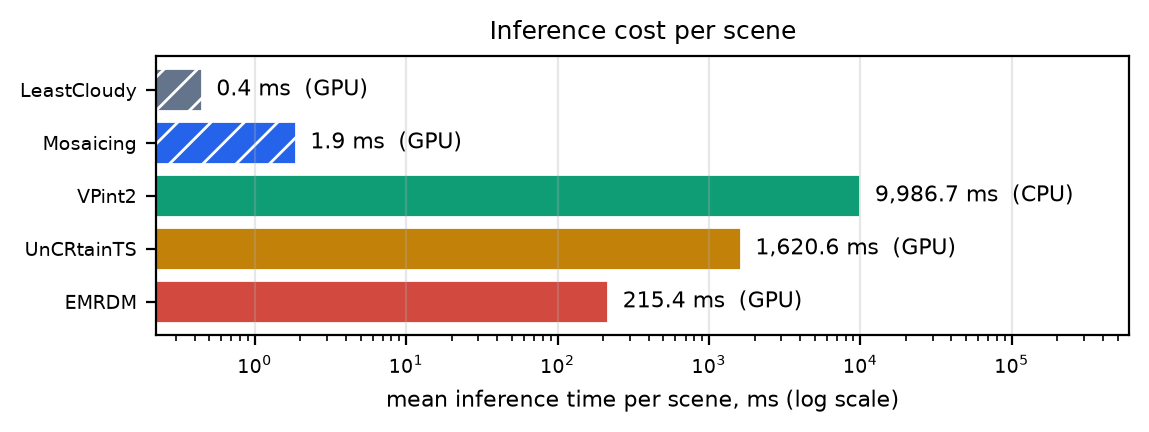

LeastCloudy       0.4
Mosaicing         1.9
VPint2         9986.7
UnCRtainTS     1620.6
EMRDM           215.4


In [9]:
# Timing is recorded as ms_per_sample by every benchmark run. The thesis numbers came from a
# dedicated timing run (predictions were not saved, so it is kept separate from the main
# outputs); a fresh run records timing alongside the metrics, so fall back to those.
_timing_run = ROOT / "outputs_timing" / "AllClear" / "intersection_samples"
TIMING_ROOT = _timing_run if _timing_run.exists() else DATA_ROOT
print(f"Timing source: {TIMING_ROOT.relative_to(ROOT)}")
DEVICE = {"LeastCloudy": "GPU", "Mosaicing": "GPU", "VPint2": "CPU",
          "UnCRtainTS": "GPU", "EMRDM": "GPU"}

ms_per_scene = pd.Series(
    {m: pd.read_csv(TIMING_ROOT / f"{m}_aggregated_metrics.csv")["ms_per_sample"].iloc[0]
     for m in MODELS})

fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN, 2.2), dpi=200)
bars = ax.barh(MODELS, ms_per_scene[MODELS].values,
               color=[MODEL_COLORS[m] for m in MODELS],
               # baselines are the reference point, not methods under test
               hatch=["//" if m in BASELINES else "" for m in MODELS],
               edgecolor="white")
for bar, m in zip(bars, MODELS):
    ax.text(ms_per_scene[m] * 1.25, bar.get_y() + bar.get_height() / 2,
            f"{ms_per_scene[m]:,.1f} ms  ({DEVICE[m]})", va="center")
ax.set_xscale("log")
ax.set_xlim(ms_per_scene.min() * 0.5, ms_per_scene.max() * 60)
ax.invert_yaxis()
ax.set_xlabel("mean inference time per scene, ms (log scale)")
ax.set_title("Inference cost per scene")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(OUT_PLOTS / "inference_cost.pdf")
plt.show()
plt.close(fig)

print(ms_per_scene[MODELS].round(1).to_string())


## RQ2: Spectral index preservation

- Does the reconstruction still work for the derived indices actually used in remote sensing (NDVI, NBR), not just raw pixels?
- Looking at NDVI_MAE and NBR_MAE — lower is better for both.

### Does pixel accuracy predict index accuracy?

- A practitioner computing NDVI wants to know whether the usual pixel metrics (MAE, PSNR) are a safe guide when choosing a method.
- Here each method is one point: its pixel error on the x-axis, its index error on the y-axis, both in their own units.
- The dashed line is what proportional behaviour would look like — index error rising in step with pixel error.
- A method above the line distorts the index more than its pixel score suggests. A method below it does better on indices than its pixel score suggests.


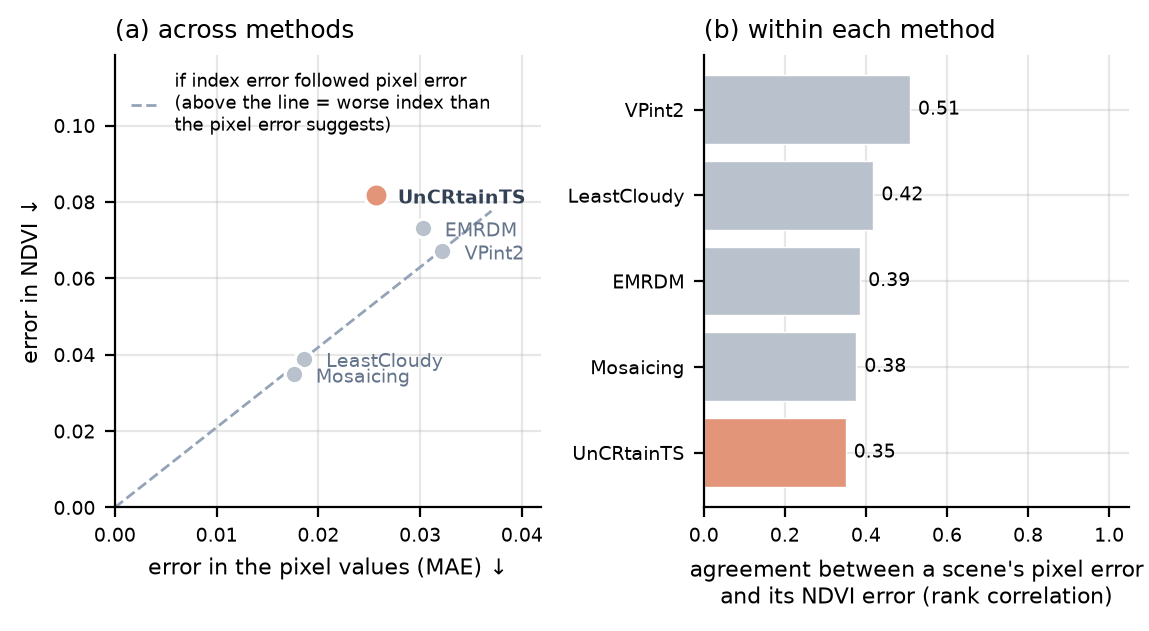

NDVI_MAE / MAE ratio: {'LeastCloudy': 2.1, 'Mosaicing': 1.98, 'VPint2': 2.09, 'UnCRtainTS': 3.19, 'EMRDM': 2.42}
NBR_MAE / MAE ratio: {'LeastCloudy': 3.43, 'Mosaicing': 3.18, 'VPint2': 3.12, 'UnCRtainTS': 4.12, 'EMRDM': 3.76}
rank correlation MAE vs NDVI_MAE: {'LeastCloudy': 0.42, 'Mosaicing': 0.38, 'VPint2': 0.51, 'UnCRtainTS': 0.35, 'EMRDM': 0.39}
rank correlation MAE vs NBR_MAE: {'LeastCloudy': 0.41, 'Mosaicing': 0.49, 'VPint2': 0.67, 'UnCRtainTS': 0.36, 'EMRDM': 0.44}


In [10]:
agg = agg_df.set_index("model")
OUTLIER = "UnCRtainTS"   # the method both panels are about

# (a) compares methods: is a method's index error worse than its pixel error suggests?
# (b) looks inside each method: across its 366 scenes, does pixel error predict index error?
# Two different questions -- a method can do well on one and badly on the other.
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(TEXT_WIDTH_IN, 3.2), dpi=200)

x, y = agg.loc[MODELS, "MAE"], agg.loc[MODELS, "NDVI_MAE"]
ratio = (y / x).median()          # index error simply proportional to pixel error
xs = np.linspace(0, x.max() * 1.15, 50)
ax_a.plot(xs, ratio * xs, ls="--", color="#94a3b8", lw=1, zorder=1)
for m in MODELS:
    emph = m == OUTLIER
    ax_a.scatter(x[m], y[m], s=70 if emph else 45, color=CLAY if emph else "#b9c2cc",
                 zorder=3, edgecolor="white", linewidth=1.2)
    ax_a.annotate(m, (x[m], y[m]), textcoords="offset points", xytext=(8, -3), fontsize=7,
                  fontweight="bold" if emph else "normal",
                  color="#334155" if emph else "#64748b")
ax_a.plot([], [], ls="--", color="#94a3b8", lw=1,
          label="if index error followed pixel error\n(above the line = worse index than\nthe pixel error suggests)")
ax_a.legend(loc="upper left", fontsize=6.5, handlelength=1.6, borderpad=0.4, frameon=False)
ax_a.set_xlabel("error in the pixel values (MAE) \u2193")
ax_a.set_ylabel("error in NDVI \u2193")
ax_a.set_title("(a) across methods", loc="left")
ax_a.set_xlim(0, x.max() * 1.3)
ax_a.set_ylim(0, y.max() * 1.45)

# (b) Spearman rank correlation per method, computed over its own 366 scenes. Rank-based
# because only the ordering of scenes matters, not the size of the errors.
rho = pd.Series({m: long_df.loc[long_df.model == m, "MAE"]
                 .corr(long_df.loc[long_df.model == m, "NDVI_MAE"], method="spearman")
                 for m in MODELS}).sort_values()
ax_b.barh(rho.index, rho.values,
          color=[CLAY if m == OUTLIER else "#b9c2cc" for m in rho.index],
          edgecolor="white", linewidth=0.5)
for i, v in enumerate(rho.values):
    ax_b.text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=7)
ax_b.set_xlim(0, 1.05)
ax_b.set_xlabel("agreement between a scene's pixel error\nand its NDVI error (rank correlation)")
ax_b.set_title("(b) within each method", loc="left")

for ax in (ax_a, ax_b):
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_PLOTS / "rq2_pixel_vs_index.pdf")
plt.show()
plt.close(fig)

for index_metric in RATIO_METRICS:
    print(f"{index_metric} / MAE ratio:",
          {m: round(agg.loc[m, index_metric] / agg.loc[m, "MAE"], 2) for m in MODELS})
for index_metric in RATIO_METRICS:
    print(f"rank correlation MAE vs {index_metric}:",
          {m: round(long_df.loc[long_df.model == m, "MAE"]
                    .corr(long_df.loc[long_df.model == m, index_metric], method="spearman"), 2)
           for m in MODELS})


### Does the mismatch run both ways?

- Figure 4.3 shows pixel accuracy and index accuracy come apart. This asks how often, and in which direction.
- For each method, split its 366 scenes into quartiles on pixel error and on NDVI error, then count the two opposite corners.
- **Good pixels, bad NDVI** is the case a practitioner worries about: the reconstruction scores well but the index is unusable.
- **Bad pixels, good NDVI** is the reverse: the reconstruction scores poorly but the index is fine anyway.


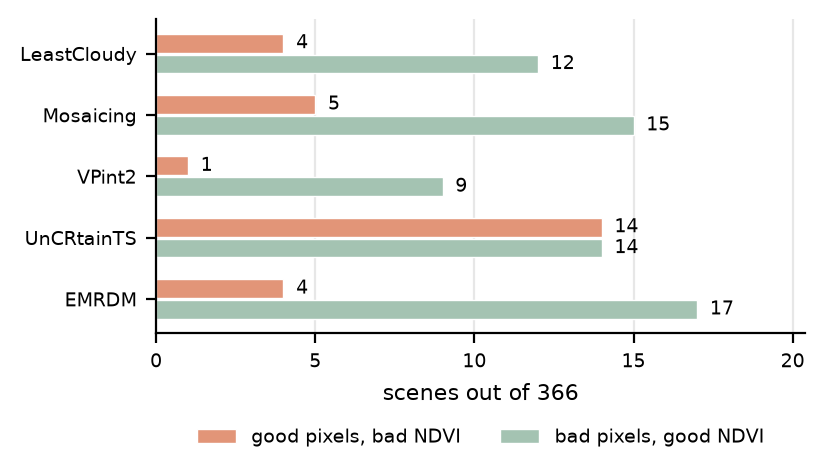

             good pixels, bad NDVI  bad pixels, good NDVI
LeastCloudy                      4                     12
Mosaicing                        5                     15
VPint2                           1                      9
UnCRtainTS                      14                     14
EMRDM                            4                     17

benchmarked methods only: {'good pixels, bad NDVI': 19, 'bad pixels, good NDVI': 40}


In [11]:
# Quartile corners per method. A "corner" scene is in the best quarter on one error and the
# worst quarter on the other, so the two counts say how often the two error types disagree
# and in which direction. Quartiles are taken per method, so each count is relative to that
# method's own distribution rather than to a shared threshold.
def corner_counts(df, pixel="MAE", index="NDVI_MAE"):
    pix_best, pix_worst = df[pixel].quantile(.25), df[pixel].quantile(.75)
    idx_best, idx_worst = df[index].quantile(.25), df[index].quantile(.75)
    return pd.Series({
        "good pixels, bad NDVI": int(((df[pixel] <= pix_best) & (df[index] >= idx_worst)).sum()),
        "bad pixels, good NDVI": int(((df[pixel] >= pix_worst) & (df[index] <= idx_best)).sum()),
    })


corners = pd.DataFrame({m: corner_counts(long_df[long_df.model == m]) for m in MODELS}).T

fig, ax = plt.subplots(figsize=(0.72 * TEXT_WIDTH_IN, 2.6), dpi=200)
y, h = np.arange(len(MODELS)), 0.34
for offset, (col, colour) in zip((-h / 2, h / 2),
                                 [("good pixels, bad NDVI", CLAY),
                                  ("bad pixels, good NDVI", SAGE)]):
    ax.barh(y + offset, corners.loc[MODELS, col], height=h * 0.9, color=colour,
            edgecolor="white", linewidth=0.5, label=col)
    for yi, v in zip(y + offset, corners.loc[MODELS, col]):
        ax.text(v + 0.4, yi, str(v), va="center", fontsize=7)

ax.set_yticks(y)
ax.set_yticklabels(MODELS)
ax.invert_yaxis()
ax.set_xlim(0, corners.values.max() * 1.2)
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.set_xlabel("scenes out of 366")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.42), ncol=2, frameon=False)
ax.grid(alpha=0.3, axis="x")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_PLOTS / "rq2_corner_cases.pdf")
plt.show()
plt.close(fig)

print(corners.to_string())
print("\nbenchmarked methods only:", corners.loc[LEARNED].sum().to_dict())


### Careful: part of the index error comes from the metric, not the model

- NDVI is a ratio, `(NIR - Red) / (NIR + Red)`, so on dark scenes it divides by a small number and turns small band errors into large index errors.
- To check whether that matters here we group the scenes by brightness (mean NIR + Red of the prediction) and plot both metrics.
- If index error only reflected reconstruction quality it would follow MAE. It does the opposite, so some of the index error is arithmetic rather than a model problem.

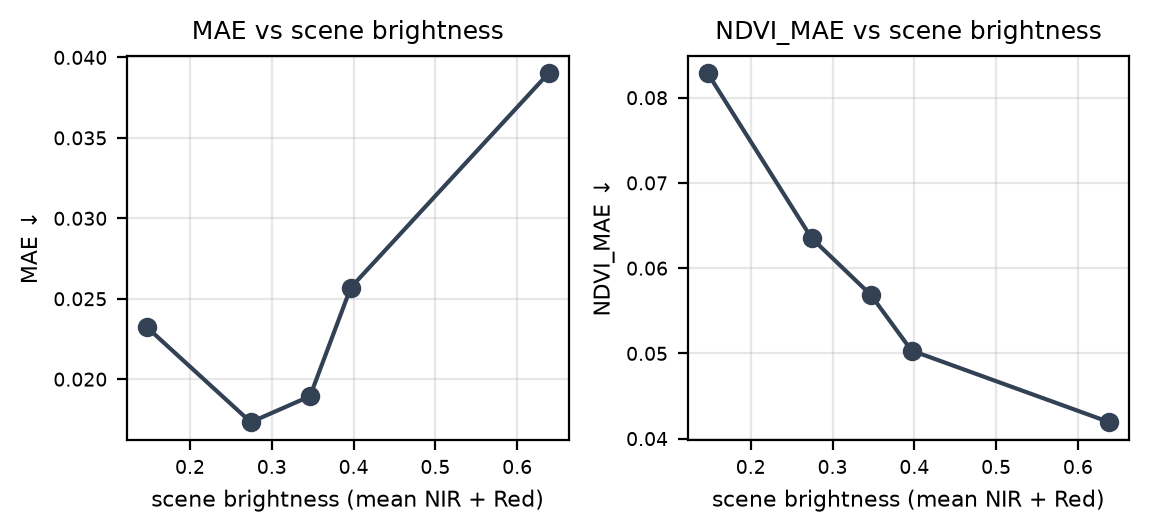

       brightness     MAE  NDVI_MAE
group                              
0          0.1473  0.0232    0.0829
1          0.2744  0.0173    0.0635
2          0.3468  0.0189    0.0569
3          0.3965  0.0257    0.0503
4          0.6384  0.0390    0.0419

19 cases with best-quartile MAE and worst-quartile NDVI_MAE
darker than the median scene: 19
median brightness 0.098 vs 0.349 overall


In [12]:
import torch

# NDVI = (NIR - Red) / (NIR + Red). The denominator is what shrinks on dark scenes, so we use it
# as the brightness measure. Band indices are the ones metrics.py uses (7 = NIR, 3 = Red).
# Read off LeastCloudy, which copies the least-cloudy input frame, so brightness describes the
# scene. Using each model's own output would let a model that over-brightens shift its own bin.
pred = torch.load(DATA_ROOT / f"{BASELINE}_predictions.pt", map_location="cpu", weights_only=False)
ids = pd.read_csv(DATA_ROOT / f"{BASELINE}_metadata.csv")["data_id"]
scene_brightness = pd.Series((pred[:, 7, 0] + pred[:, 3, 0]).mean(dim=(1, 2)).numpy(), index=ids)

bright_df = long_df.assign(brightness=long_df.data_id.map(scene_brightness))
bright_df["group"] = pd.qcut(bright_df.brightness, 5, labels=False)
grouped = bright_df.groupby("group").agg(
    brightness=("brightness", "mean"), MAE=("MAE", "mean"), NDVI_MAE=("NDVI_MAE", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(TEXT_WIDTH_IN, 2.7), dpi=200)
for ax, metric in zip(axes, ["MAE", "NDVI_MAE"]):
    ax.plot(grouped.brightness, grouped[metric], marker="o", color="#334155")
    ax.set_xlabel("scene brightness (mean NIR + Red)")
    ax.set_ylabel(f"{metric} \u2193")
    ax.set_title(f"{metric} vs scene brightness")
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_PLOTS / "rq2_brightness_effect.pdf")
plt.show()
plt.close(fig)

print(grouped.round(4).to_string())

# How many scenes look great on pixels but terrible on the index, and are they all dark?
b = bright_df[bright_df.model.isin(LEARNED)]
odd = b[(b.MAE <= b.MAE.quantile(0.25)) & (b.NDVI_MAE >= b.NDVI_MAE.quantile(0.75))]
print(f"\n{len(odd)} cases with best-quartile MAE and worst-quartile NDVI_MAE")
print(f"darker than the median scene: {(odd.brightness < scene_brightness.median()).sum()}")
print(f"median brightness {odd.brightness.median():.3f} vs {scene_brightness.median():.3f} overall")


## RQ3: Robustness across cloud and land-cover conditions

- Does model quality hold up under harder conditions — more clouds, different land types?
- Focused on NDVI_MAE and NBR_MAE, since RQ2 showed these are the metrics that matter downstream.

### Cloud impact

- All models see the same scenes with the same cloud cover, so we can put them on **one shared set of bins** and compare them directly at each cloud level.
- Baselines are drawn dashed: they're the reference "just copy the clear pixels" floor, not methods under test.
- What to look for: not just who is lowest, but **how steeply each line rises** — that is the robustness answer for RQ3.
- Bin sizes are uneven (n = 101 / 80 / 158 / 27), so the 60-100% points rest on few samples and should be read as indicative.

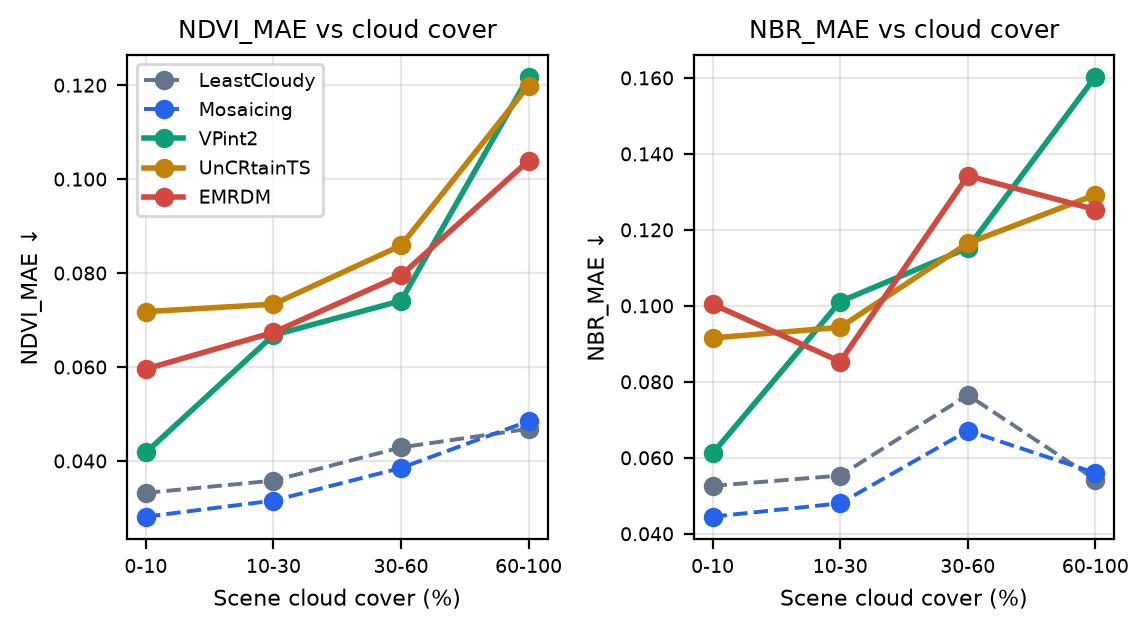

In [13]:
def cloud_impact(long_df, metrics, out_name):
    fig, axes = plt.subplots(1, len(metrics), figsize=(TEXT_WIDTH_IN, 3.2), dpi=200)
    for ax, metric in zip(axes, metrics):
        for model in MODELS:
            means = (long_df.loc[long_df.model == model]
                     .groupby("cloud_bin", observed=True)[metric].mean()
                     .reindex(CLOUD_BIN_LABELS))
            is_baseline = model in BASELINES
            ax.plot(CLOUD_BIN_LABELS, means.to_numpy(), marker="o",
                    color=MODEL_COLORS[model], label=model,
                    linestyle="--" if is_baseline else "-",
                    linewidth=1.4 if is_baseline else 2.0,
                    )
        ax.set_xlabel("Scene cloud cover (%)")
        ax.set_ylabel(f"{metric} ↓")
        ax.set_title(f"{metric} vs cloud cover")
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
        ax.grid(alpha=0.3)
    axes[0].legend(loc="upper left")
    fig.tight_layout()
    fig.savefig(OUT_PLOTS / f"{out_name}.pdf")
    plt.show()
    plt.close(fig)


cloud_impact(long_df, RATIO_METRICS, "rq3_cloud_impact")

### Land-cover heatmap

- Mean NDVI_MAE/NBR_MAE per land-cover class (Dynamic World classes), for the three learned models.
- Baselines are left out here: they win almost every class, which flattens the colour scale and hides the differences between the methods we actually want to compare.
- All 9 classes are kept — the point is to see *where* each model struggles, so collapsing them would throw away the answer.

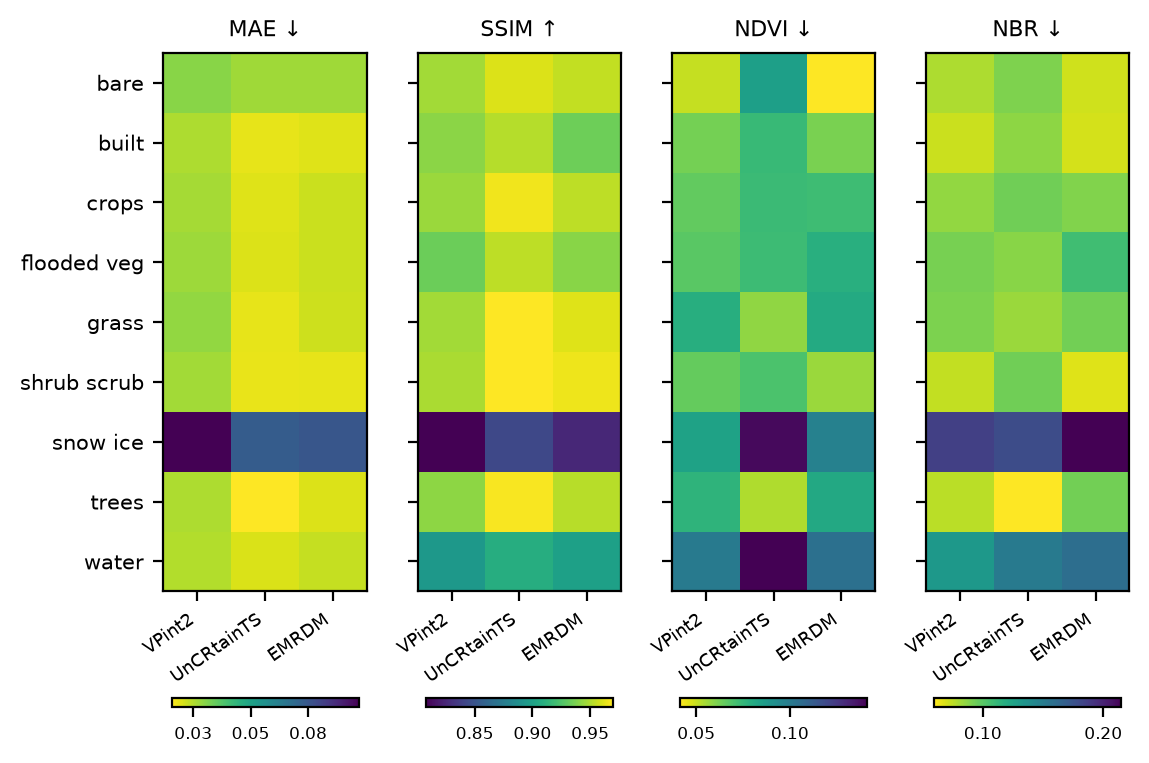

In [14]:
# Metrics shown per land-cover class: the two reconstruction metrics that RQ1 is built on,
# plus the two indices. PSNR is left out because it is a function of RMSE, and SAM because
# the index panels already cover spectral behaviour.
LULC_METRICS = ["MAE", "SSIM"] + RATIO_METRICS


def lulc_heatmap(lulc_df, metrics, out_name, models=LEARNED):
    # Land-cover classes go on the vertical axis: nine names do not fit side by side across
    # a quarter of the text width, and horizontal labels are readable where rotated ones are not.
    fig, axes = plt.subplots(1, len(metrics), figsize=(TEXT_WIDTH_IN, 4.2), dpi=200)
    for k, (ax, metric) in enumerate(zip(np.atleast_1d(axes), metrics)):
        pivot = lulc_df.pivot_table(index="model", columns="class_name", values=metric,
                                    aggfunc="first").reindex(models).T
        # higher SSIM is better, so invert the ramp to keep "dark = worse" across all panels
        cmap = "viridis" if metric in HIGHER_IS_BETTER else "viridis_r"
        im = ax.imshow(pivot.to_numpy(), cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=6.5, rotation=35, ha="right")
        ax.set_yticks(range(len(pivot.index)))
        if k == 0:
            ax.set_yticklabels([c.replace("_", " ") for c in pivot.index], fontsize=7.5)
        else:
            ax.set_yticklabels([])          # shared rows: label them once
        ax.set_title(metric.replace("_MAE", "") + (" \u2191" if metric in HIGHER_IS_BETTER
                                                   else " \u2193"), fontsize=8)
        # colour bar below the panel, not beside it: the width is needed for the model names
        cb = fig.colorbar(im, ax=ax, orientation="horizontal", shrink=0.92, pad=0.14,
                          format="%.2f")
        cb.ax.tick_params(labelsize=6)
    fig.tight_layout(w_pad=1.2)
    fig.savefig(OUT_PLOTS / f"{out_name}.pdf")
    plt.show()
    plt.close(fig)



lulc_heatmap(lulc_df, LULC_METRICS, "rq3_lulc_heatmap")

### Why water and snow/ice are the hardest classes

The heatmap shows every method doing worst on water and snow/ice. Two checks on the saved predictions, using LeastCloudy as the stand-in for observed data since it just copies an input frame:

- **Left:** predicted brightness (NIR + Red) on the darkest and brightest 20% of scenes. A method that reproduced the scene faithfully would sit on the LeastCloudy line.
- **Right:** scene-mean NDVI on the darkest 20%. Water is dark, so a bias shows up here.


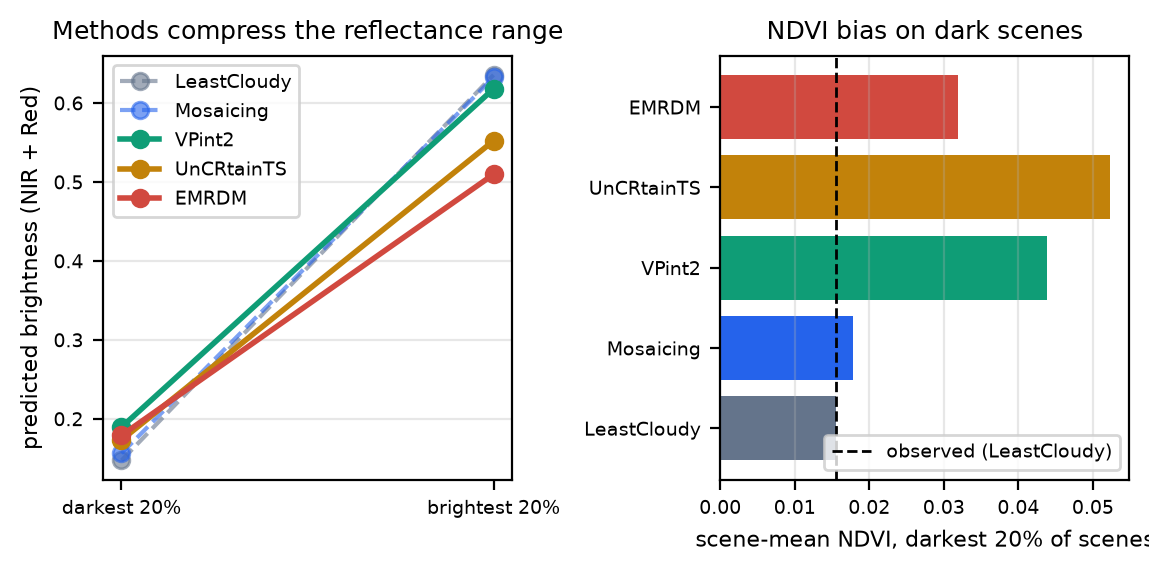

mean NIR+Red
  LeastCloudy  dark 0.147   bright 0.636
  Mosaicing    dark 0.156   bright 0.632
  VPint2       dark 0.189   bright 0.618
  UnCRtainTS   dark 0.173   bright 0.552
  EMRDM        dark 0.179   bright 0.510

scene-mean NDVI on darkest 20%
  LeastCloudy  +0.016
  Mosaicing    +0.018
  VPint2       +0.044
  UnCRtainTS   +0.052
  EMRDM        +0.032


In [15]:
# Both checks reuse the prediction tensors, no rerun needed.
bands = {}
for model in MODELS:
    pred = torch.load(DATA_ROOT / f"{model}_predictions.pt", map_location="cpu", weights_only=False)
    idx = pd.read_csv(DATA_ROOT / f"{model}_metadata.csv")["data_id"]
    nir, red = pred[:, 7, 0].mean(dim=(1, 2)), pred[:, 3, 0].mean(dim=(1, 2))
    bands[model] = pd.DataFrame({"sum": (nir + red).numpy(),
                                 "ndvi": ((nir - red) / (nir + red)).numpy()}, index=idx)

dark = scene_brightness[scene_brightness <= scene_brightness.quantile(0.2)].index
bright = scene_brightness[scene_brightness >= scene_brightness.quantile(0.8)].index

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXT_WIDTH_IN, 2.9), dpi=200)
for model in MODELS:
    style = dict(ls="--", alpha=0.6) if model in BASELINES else dict(ls="-", lw=2)
    ax1.plot([0, 1], [bands[model]["sum"][dark].mean(), bands[model]["sum"][bright].mean()],
             marker="o", color=MODEL_COLORS[model], label=model, **style)
ax1.set_xticks([0, 1], ["darkest 20%", "brightest 20%"])
ax1.set_ylabel("predicted brightness (NIR + Red)")
ax1.set_title("Methods compress the reflectance range")
ax1.legend()
ax1.grid(alpha=0.3, axis="y")

vals = [bands[m]["ndvi"][dark].mean() for m in MODELS]
ax2.barh(MODELS, vals, color=[MODEL_COLORS[m] for m in MODELS])
ax2.axvline(vals[MODELS.index(BASELINE)], color="black", ls="--", lw=1,
            label=f"observed ({BASELINE})")
ax2.set_xlabel("scene-mean NDVI, darkest 20% of scenes")
ax2.set_title("NDVI bias on dark scenes")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.3, axis="x")

fig.tight_layout()
fig.savefig(OUT_PLOTS / "rq3_extreme_surfaces.pdf")
plt.show()
plt.close(fig)

print("mean NIR+Red")
for m in MODELS:
    print(f"  {m:12s} dark {bands[m]['sum'][dark].mean():.3f}   bright {bands[m]['sum'][bright].mean():.3f}")
print("\nscene-mean NDVI on darkest 20%")
for m in MODELS:
    print(f"  {m:12s} {bands[m]['ndvi'][dark].mean():+.3f}")


### Appendix: cloud degradation delta

- Same data as the plot above, boiled down to one number per model: mean metric in the 60-100% cloud bin minus the 0-10% bin.
- Bigger bar = that model loses more quality as cloud increases. This is the compact version of the "how steep is the line" question.

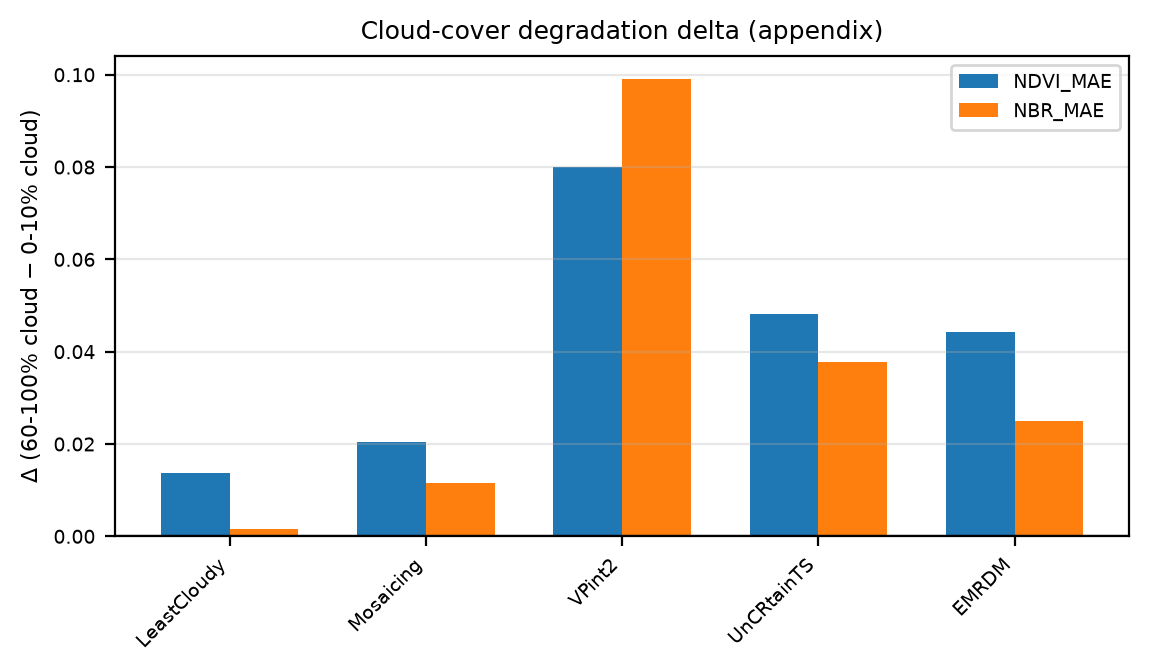

,model,metric,low_cloud_mean,high_cloud_mean,delta_high_minus_low
0,LeastCloudy,NDVI_MAE,0.033202,0.046836,0.013635
1,LeastCloudy,NBR_MAE,0.052606,0.054282,0.001676
2,Mosaicing,NDVI_MAE,0.028138,0.048475,0.020337
3,Mosaicing,NBR_MAE,0.044500,0.055998,0.011498
4,VPint2,NDVI_MAE,0.041804,0.121812,0.080009
5,VPint2,NBR_MAE,0.061160,0.160331,0.099171
6,UnCRtainTS,NDVI_MAE,0.071782,0.119932,0.048150
7,UnCRtainTS,NBR_MAE,0.091540,0.129215,0.037675
8,EMRDM,NDVI_MAE,0.059581,0.103929,0.044348
9,EMRDM,NBR_MAE,0.100436,0.125335,0.024900


In [16]:
def cloud_delta_appendix(long_df, metrics, out_name):
    rows = []
    for model in MODELS:
        sub = long_df.loc[long_df.model == model]
        for metric in metrics:
            low = sub.loc[sub.cloud_bin == "0-10", metric].mean()
            high = sub.loc[sub.cloud_bin == "60-100", metric].mean()
            rows.append({
                "model": model, "metric": metric,
                "low_cloud_mean": low, "high_cloud_mean": high,
                "delta_high_minus_low": high - low,
            })
    table = pd.DataFrame(rows)
    table.to_csv(OUT_TABLES / "rq3_appendix_cloud_delta.csv", index=False)

    fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN, 3.4), dpi=200)
    width = 0.35
    x = np.arange(len(MODELS))
    for i, metric in enumerate(metrics):
        sub = table.loc[table.metric == metric].set_index("model").loc[MODELS]
        ax.bar(x + i * width, sub["delta_high_minus_low"], width, label=metric)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(MODELS, rotation=45, ha="right")
    ax.set_ylabel("Δ (60-100% cloud − 0-10% cloud)")
    ax.set_title("Cloud-cover degradation delta (appendix)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(OUT_PLOTS / f"{out_name}.pdf")
    plt.show()
    plt.close(fig)
    return table


rq3_cloud_delta_table = cloud_delta_appendix(long_df, RATIO_METRICS, "rq3_appendix_cloud_delta")
rq3_cloud_delta_table

### Decision table: best learned model per condition

- "If you had to pick one method under condition X, which one?" — split by cloud bin and by land-cover class.
- Baselines are excluded: they win nearly everything, so including them would make every row say "Mosaicing" and answer nothing useful about the methods under test.
- Cloud bins are shared across models, so a single winner per bin is well defined.

In [17]:
CLASS_LABELS = {"flooded_veg": "flooded veg.", "shrub_scrub": "shrub/scrub", "snow_ice": "snow/ice"}


def decision_table(long_df, lulc_df, metrics, models=LEARNED):
    rows = []
    for metric in metrics:
        # by cloud bin (shared bins, so a single winner is well defined)
        sub = long_df.loc[long_df.model.isin(models)]
        for cloud_bin in CLOUD_BIN_LABELS:
            means = sub.loc[sub.cloud_bin == cloud_bin].groupby("model")[metric].mean()
            if means.empty:
                continue
            rows.append({"scope": "cloud_bin", "condition": f"{cloud_bin}%", "metric": metric,
                         "best_model": means.idxmin(), "best_value": means.min()})
        # by land-cover class
        for class_id, class_name in DW_CLASS_NAMES.items():
            means = (lulc_df.loc[(lulc_df["class"] == class_id) & lulc_df.model.isin(models)]
                     .set_index("model")[metric].dropna())
            if means.empty:
                continue
            rows.append({"scope": "lulc_class", "condition": class_name, "metric": metric,
                         "best_model": means.idxmin(), "best_value": means.min()})
    table = pd.DataFrame(rows)
    table.to_csv(OUT_TABLES / "rq3_decision_table.csv", index=False)
    return table


def write_decision_latex(table, path, models=LEARNED):
    """One row per (index, method): which conditions that method wins.
    Avoids footnote markers by listing the two indices separately."""
    lines = [r"\begin{tabular}{llll}", r"\toprule",
             r"Index & Method & Best under cloud cover & Best on land cover \\"]
    for metric in RATIO_METRICS:
        lines.append(r"\midrule")
        sub = table[table.metric == metric]
        for i, model in enumerate(models):
            won = sub[sub.best_model == model]
# en-dash for numeric ranges, and escape the percent sign for LaTeX
            cloud = ", ".join(r.condition.replace("-", "--").replace("%", r"\%")
                              for r in won.itertuples() if r.scope == "cloud_bin")
            land = ", ".join(CLASS_LABELS.get(r.condition, r.condition)
                             for r in won.itertuples() if r.scope == "lulc_class")
            label = metric.replace("_", r"\_") if i == 0 else ""
            lines.append(f"{label} & {model} & {cloud or '--'} & {land or '--'} " + r"\\")
    lines += [r"\bottomrule", r"\end{tabular}"]
    path.write_text("\n".join(lines) + "\n")


rq3_decision_table = decision_table(long_df, lulc_df, RATIO_METRICS)
write_decision_latex(rq3_decision_table, OUT_TABLES / "rq3_decision_table.tex")
rq3_decision_table

,scope,condition,metric,best_model,best_value
0,cloud_bin,0-10%,NDVI_MAE,VPint2,0.041804
1,cloud_bin,10-30%,NDVI_MAE,VPint2,0.066786
2,cloud_bin,30-60%,NDVI_MAE,VPint2,0.074110
3,cloud_bin,60-100%,NDVI_MAE,EMRDM,0.103929
4,lulc_class,water,NDVI_MAE,VPint2,0.099979
5,lulc_class,trees,NDVI_MAE,UnCRtainTS,0.053359
6,lulc_class,grass,NDVI_MAE,UnCRtainTS,0.057871
7,lulc_class,flooded_veg,NDVI_MAE,VPint2,0.067029
8,lulc_class,crops,NDVI_MAE,VPint2,0.065276
9,lulc_class,shrub_scrub,NDVI_MAE,EMRDM,0.056508


### What cloud did EMRDM actually face?

- The cloud percentage used in RQ3 is the mean over **all** input frames the dataset supplies, so it describes the scene.
- EMRDM does not get the frame stack. The pair selector hands it one deliberately cloudy Sentinel-2 frame, and records how clouded that frame is in `setup/emrdm_pairs.json`.
- So for EMRDM the scene label and its real input can differ a lot. This cell measures by how much, and what it does to the comparison.
- LeastCloudy is the control: if these scenes were simply difficult, a method that just copies the clearest frame would do badly on them too.


In [18]:
# The cloud axis in RQ3 describes the scene. EMRDM's own input is a single frame chosen by the
# pair selector, whose cloudiness is recorded in setup/emrdm_pairs.json -- a different number.
# Cited in the RQ3 text, so it is computed here rather than typed into the thesis by hand.
EMRDM_PAIRS = ROOT / "setup" / "emrdm_pairs.json"   # the file setup.sh passes to benchmark.py
HEAVY_CLOUD = 0.90

pair_meta = json.loads(EMRDM_PAIRS.read_text())
scene_ids = long_df.loc[long_df.model == "EMRDM", "data_id"]
missing = [i for i in scene_ids if i not in pair_meta]
assert not missing, f"{len(missing)} scenes absent from {EMRDM_PAIRS.name}"

emrdm_frame_cloud = pd.Series({i: pair_meta[i]["s2_cloudy_fraction"] for i in scene_ids})
heavy = emrdm_frame_cloud[emrdm_frame_cloud > HEAVY_CLOUD].index


def on(model, ids, metric):
    sub = long_df[long_df.model == model].set_index("data_id")
    return sub.loc[ids, metric].mean()


effective_cloud = pd.DataFrame({
    "all 366 scenes": {m: on(m, scene_ids, "NDVI_MAE") for m in MODELS},
    f"EMRDM frame >{HEAVY_CLOUD:.0%} clouded": {m: on(m, heavy, "NDVI_MAE") for m in MODELS},
})

print(f"EMRDM's own frame is >{HEAVY_CLOUD:.0%} clouded on {len(heavy)} of {len(scene_ids)} scenes")
print(f"  mean scene-level cloud on those: {on('EMRDM', heavy, 'cloud_pct'):.1f}% "
      f"-- they are not unusually cloudy scenes")
print("\nNDVI_MAE:")
print(effective_cloud.round(3).to_string())
print(f"\nLeastCloudy MAE there: {on('LeastCloudy', heavy, 'MAE'):.4f} "
      f"(all scenes: {on('LeastCloudy', scene_ids, 'MAE'):.4f})")


EMRDM's own frame is >90% clouded on 76 of 366 scenes
  mean scene-level cloud on those: 41.4% -- they are not unusually cloudy scenes

NDVI_MAE:
             all 366 scenes  EMRDM frame >90% clouded
LeastCloudy           0.039                     0.041
Mosaicing             0.035                     0.041
VPint2                0.067                     0.081
UnCRtainTS            0.082                     0.085
EMRDM                 0.073                     0.101

LeastCloudy MAE there: 0.0132 (all scenes: 0.0186)


## Hard scenes: what happens when no clear frame exists

- The main evaluation set keeps only scenes containing a near-clear frame, because VPint2 requires one. That is the condition the frame-selecting baselines are built for, and RQ1 showed they win most scenes because of it.
- This run removes that condition: 268 scenes where **no** input frame is usable. VPint2 cannot run at all, so four methods remain.
- Same benchmark code, same metrics, same checkpoints. Only the eligibility rule changed.
- The cell also checks how clouded EMRDM's own frame is here, so its result cannot be attributed to favourable frame selection.


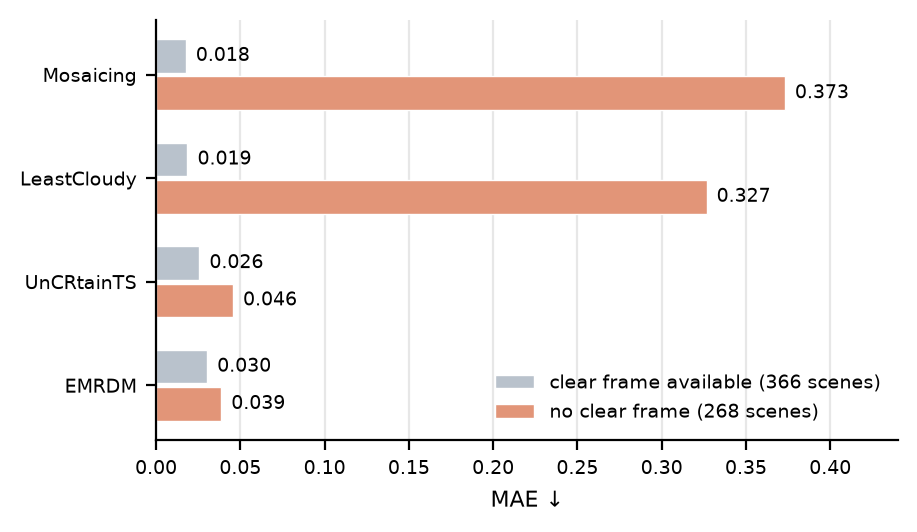

VPint2 excluded: cannot run without a clear reference frame
EMRDM's own optical frame here: mean 99.8% clouded, >90% on 268 of 268 scenes

MAE, main set vs hard set:
             366 scenes  268 hard scenes  factor
LeastCloudy       0.019            0.327  17.581
Mosaicing         0.018            0.373  21.228
UnCRtainTS        0.026            0.046   1.779
EMRDM             0.030            0.039   1.277

share of the 268 hard scenes with the lowest MAE (%):
LeastCloudy     2.2
Mosaicing       0.0
UnCRtainTS     30.6
EMRDM          67.2


In [19]:
# Separate run: outputs_hard/ holds the 268-scene subset in which no clear frame exists.
# Read directly rather than through DATA_ROOT, which points at the 366-scene evaluation set.
HARD_ROOT = ROOT / "outputs_hard" / "AllClear" / "hard_subset"
HARD_MODELS = [m for m in MODELS if (HARD_ROOT / f"{m}_aggregated_metrics.csv").exists()]
# the indices matter as much as the reconstruction metrics here, so report both families
HARD_METRICS = RECON_METRICS + RATIO_METRICS

hard = pd.DataFrame({
    m: pd.read_csv(HARD_ROOT / f"{m}_aggregated_metrics.csv").iloc[0] for m in HARD_MODELS
}).T[HARD_METRICS]
easy = agg_df.set_index("model").loc[HARD_MODELS, HARD_METRICS]

# EMRDM's optical input on these scenes, from the same pair file used for the RQ3 check --
# rules out its lead here being an effect of which frame it happened to be handed.
hard_ids = pd.read_csv(HARD_ROOT / "EMRDM_metadata.csv")["data_id"]
# Scene-by-scene, same counting rule as Figure 4.2: does the aggregate ordering hold, or is
# it carried by a subset of scenes? Reported as a column of the table below.
hard_per_scene = pd.DataFrame({
    m: pd.read_csv(HARD_ROOT / f"{m}_metadata.csv").set_index("data_id")["mae"]
    for m in HARD_MODELS
})
hard_win = ((hard_per_scene.idxmin(axis=1).value_counts() / len(hard_per_scene) * 100)
            .reindex(HARD_MODELS).fillna(0))

hard_frame_cloud = pd.Series({i: pair_meta[i]["s2_cloudy_fraction"] for i in hard_ids})

fig, ax = plt.subplots(figsize=(0.8 * TEXT_WIDTH_IN, 2.7), dpi=200)
order = easy["MAE"].sort_values().index          # ordered by the main set, so the flip is visible
y, h = np.arange(len(order)), 0.36
ax.barh(y - h / 2, easy.loc[order, "MAE"], height=h * 0.9, color="#b9c2cc",
        edgecolor="white", linewidth=0.5, label="clear frame available (366 scenes)")
ax.barh(y + h / 2, hard.loc[order, "MAE"], height=h * 0.9, color=CLAY,
        edgecolor="white", linewidth=0.5, label="no clear frame (268 scenes)")
for yi, v in zip(y - h / 2, easy.loc[order, "MAE"]):
    ax.text(v + 0.006, yi, f"{v:.3f}", va="center", fontsize=7)
for yi, v in zip(y + h / 2, hard.loc[order, "MAE"]):
    ax.text(v + 0.006, yi, f"{v:.3f}", va="center", fontsize=7)
ax.set_yticks(y)
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlim(0, hard["MAE"].max() * 1.18)
ax.set_xlabel("MAE \u2193")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3, axis="x")
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_PLOTS / "rq4_hard_scenes.pdf")
plt.show()
plt.close(fig)

COLS = HARD_METRICS + ["share"]

rows = ["\\begin{tabular}{|l|" + "c|" * len(COLS) + "}", "\\hline",
        "\\rowcolor{lightgray} Model & "
        + " & ".join(f"{m.replace('_', chr(92) + '_')} "
                     f"{'$\\uparrow$' if m in HIGHER_IS_BETTER else '$\\downarrow$'}"
                     for m in HARD_METRICS)
        + " & scenes won \\\\", "\\hline"]
for m in hard.index:
    best = [hard[c].max() if c in HIGHER_IS_BETTER else hard[c].min() for c in HARD_METRICS]
    cells = [f"\\textbf{{{v:.3f}}}" if v == b else f"{v:.3f}"
             for v, b in zip(hard.loc[m, HARD_METRICS], best)]
    share = hard_win[m]
    cells.append(f"\\textbf{{{share:.0f}\\,\\%}}" if share == hard_win.max()
                 else f"{share:.0f}\\,\\%")
    rows += [f"{m} & " + " & ".join(cells) + " \\\\", "\\hline"]
rows.append("\\end{tabular}")
(OUT_TABLES / "rq4_hard_scenes.tex").write_text("\n".join(rows) + "\n")

print(f"VPint2 excluded: cannot run without a clear reference frame")
print(f"EMRDM's own optical frame here: mean {hard_frame_cloud.mean():.1%} clouded, "
      f">90% on {(hard_frame_cloud > 0.90).sum()} of {len(hard_ids)} scenes")
print("\nMAE, main set vs hard set:")
print(pd.DataFrame({"366 scenes": easy["MAE"], "268 hard scenes": hard["MAE"],
                    "factor": hard["MAE"] / easy["MAE"]}).round(3).to_string())

# Scene-by-scene, same counting rule as Figure 4.2: does the aggregate ordering hold, or is it
# carried by a subset of scenes? Cited in the Section 4.5 text, so computed here.
hard_per_scene = pd.DataFrame({
    m: pd.read_csv(HARD_ROOT / f"{m}_metadata.csv").set_index("data_id")["mae"]
    for m in HARD_MODELS
})
hard_win = (hard_per_scene.idxmin(axis=1).value_counts() / len(hard_per_scene) * 100)
print("\nshare of the 268 hard scenes with the lowest MAE (%):")
print(hard_win.reindex(HARD_MODELS).fillna(0).round(1).to_string())


## Qualitative sample selection

- We only render panels for things that are actually visible in an RGB image.
- Two earlier panels were dropped after inspecting them: a "VPint2 under increasing cloud" series, where the degradation turned out to be a subtle colour shift rather than anything visible, and a "good pixels, bad index" example, which turned out to be the brightness effect above rather than a model error.
- What remains is the scene where the five reconstructions differ most. The other panels used in the thesis come from the same scene and are described in `.agents/viz-notes.md`.
- The output is the ROI list to paste into `--selected-rois` when re-running the benchmark with `--draw-vis 1` (that run produces the input/prediction/target images).

In [20]:
cloud_pct = long_df.loc[long_df.model == BASELINE].set_index("data_id")["cloud_pct"]
ndvi = long_df.pivot_table(index="data_id", columns="model", values="NDVI_MAE")[MODELS]
mae = long_df.pivot_table(index="data_id", columns="model", values="MAE")[MODELS]

# Three scenes, each answering a question the aggregate figures raise. Chosen from the metrics
# rather than by eye, so the choice is reproducible and cannot be accused of cherry-picking.
worth_removing = (cloud_pct > 30) & (cloud_pct < 95)   # something actually has to be reconstructed

picks = []

# 1. Where do the methods disagree most? The case for looking at scenes at all.
spread = (ndvi.max(axis=1) - ndvi.min(axis=1))[worth_removing]
picks.append((spread.idxmax(), "largest NDVI_MAE spread across models"))

# 2. The other end of the same range: where the methods agree most on NDVI. Note this is
#    agreement on this index only -- the other metrics can still differ on such a scene.
picks.append((spread.idxmin(), "smallest NDVI_MAE spread across models"))

# 3. The pixel-vs-index split of Figure 4.3, in one scene: UnCRtainTS reconstructs the pixels
#    better than anyone and the index worse than anyone. Restricted to scenes that are actually
#    vegetated and bright enough to render -- NDVI over dark water is near-meaningless, and an
#    illustration the reader cannot see is no illustration.
lc_pred = torch.load(DATA_ROOT / "LeastCloudy_predictions.pt", map_location="cpu",
                     weights_only=False)
lc_ids = pd.read_csv(DATA_ROOT / "LeastCloudy_metadata.csv")["data_id"]
_nir, _red = lc_pred[:, 7, 0].mean(dim=(1, 2)), lc_pred[:, 3, 0].mean(dim=(1, 2))
scene_ndvi = pd.Series(((_nir - _red) / (_nir + _red)).numpy(), index=lc_ids)
scene_brightness_rgb = pd.Series((_nir + _red).numpy(), index=lc_ids)
illustratable = worth_removing & (scene_ndvi > 0.2) & (scene_brightness_rgb > 0.15)

gap = (ndvi["UnCRtainTS"].rank(pct=True) - mae["UnCRtainTS"].rank(pct=True))[illustratable]
picks.append((gap.idxmax(), "UnCRtainTS: best-ranked pixels, worst-ranked NDVI (vegetated scene)"))

panel_selection = pd.DataFrame([{
    "data_id": data_id,
    "roi": data_id.split("_")[0],
    "cloud_pct": round(cloud_pct[data_id], 1),
    "ndvi_spread": round(float(ndvi.loc[data_id].max() - ndvi.loc[data_id].min()), 3),
    "reason": reason,
} for data_id, reason in picks])
panel_selection.to_csv(OUT_TABLES / "qualitative_selection.csv", index=False)

print("render with: .venv/bin/python3 analysis/visualise_panels.py")
panel_selection


render with: .venv/bin/python3 analysis/visualise_panels.py


,data_id,roi,cloud_pct,ndvi_spread,reason
0,roi967529_2022-03-15_2022-03-24,roi967529,64.5,0.546,largest NDVI_MAE spread across models
1,roi26795_2022-02-13_2022-02-28,roi26795,55.5,0.011,smallest NDVI_MAE spread across models
2,roi533648_2022-03-29_2022-04-13,roi533648,33.6,0.105,"UnCRtainTS: best-ranked pixels, worst-ranked N..."


## Run log

- Records when this notebook last ran and against which git commit, plus the fairness-check notes.
- Useful for tracing which run produced which set of outputs.

In [21]:
try:
    commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], cwd=ROOT, text=True,
    ).strip()
except Exception:
    commit = "unknown"

log_lines = [
    f"run_timestamp: {datetime.datetime.now().isoformat()}",
    f"git_commit: {commit}",
    "",
    "Fairness check:",
    fairness_notes,
]
(OUT_TABLES / "run_log.txt").write_text("\n".join(log_lines) + "\n")

print("Done. Wrote plots to", OUT_PLOTS, "and tables to", OUT_TABLES)

Done. Wrote plots to /Users/jessicalim/Documents/HAW/BArbeit/allclear-benchmark/outputs/thesis/plots and tables to /Users/jessicalim/Documents/HAW/BArbeit/allclear-benchmark/outputs/thesis/tables
